In [1]:
!pip install opencv-python


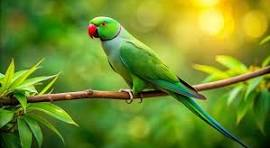

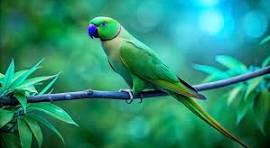

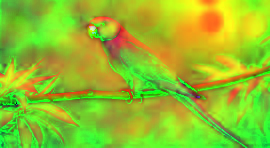

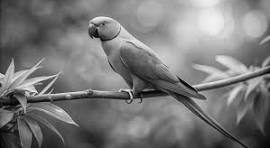

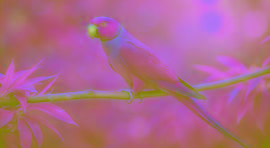

In [3]:
import cv2
from google.colab.patches import cv2_imshow

image = cv2.imread('/content/download.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

cv2_imshow(image)
cv2_imshow(image_rgb)
cv2_imshow(image_hsv)
cv2_imshow(image_gray)
cv2_imshow(image_lab)

/content/download.jpg

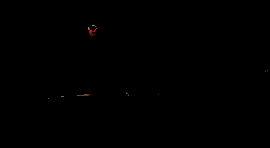

In [4]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow


image = cv2.imread('/content/download.jpg')

image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower_red = np.array([0, 120, 70])
upper_red = np.array([10, 255, 255])

mask = cv2.inRange(image_hsv, lower_red, upper_red)

result = cv2.bitwise_and(image, image, mask=mask)

cv2_imshow(result)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [5]:
# Importing the OpenCV library
import cv2
# Reading the image using imread() function
image = cv2.imread('/content/download.jpg')

# Extracting the height and width of an image
h, w = image.shape[:2]
# Displaying the height and width
print("Height = {}, Width = {}".format(h, w))

Height = 148, Width = 270


In [6]:
# Extracting RGB values.
# Here we have randomly chosen a pixel
# by passing in 100, 100 for height and width.
(B, G, R) = image[100, 100]

# Displaying the pixel values
print("R = {}, G = {}, B = {}".format(R, G, B))

# We can also pass the channel to extract
# the value for a specific channel
B = image[100, 100, 0]
print("B = {}".format(B))

R = 81, G = 107, B = 36
B = 36


In [9]:
# We are copying the original image,
# as it is an in-place operation.
output = image.copy()

# Using the rectangle() function to create a rectangle.
rectangle = cv2.rectangle(output, (1500, 900),
                        (600, 400), (255, 0, 0), 2)

object detection with yolo and opencv

In [22]:
!pip install ultralytics opencv-python

In [23]:
import cv2
import random
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

yolo model is trained on coco dataset
80 classes : person , cat , dog , etc

In [24]:
yolo = YOLO("yolov8s.pt")

In [25]:
def getColours(cls_num):
  random.seed(cls_num)
  return tuple(random.randit(0,255) for _ in range(3))

In [33]:
video_path = "/content/sample.mp4"
videoCap = cv2.VideoCapture(video_path)

video

In [37]:
def getColours(cls_num):
  random.seed(cls_num)
  return tuple(random.randint(0,255) for _ in range(3))

frame_count = 0

while True:
    ret, frame = videoCap.read()
    if not ret:
        break
    results = yolo.track(frame, stream=True)

    for result in results:
        class_names = result.names
        for box in result.boxes:
            if box.conf[0] > 0.4:
                x1, y1, x2, y2 = map(int, box.xyxy[0])

                cls = int(box.cls[0])
                class_name = class_names[cls]

                conf = float(box.conf[0])

                colour = getColours(cls)

                cv2.rectangle(frame, (x1, y1), (x2, y2), colour, 2)

                cv2.putText(frame, f"{class_name} {conf:.2f}",
                            (x1, max(y1 - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX,
                            0.6, colour, 2)

    if frame_count < 20:
        cv2_imshow(frame)
    else:
        break

    frame_count += 1

videoCap.release()

image


In [ ]:
import cv2
import random
from google.colab.patches import cv2_imshow

# 1. Define the color function
def getColours(cls_num):
    random.seed(cls_num)
    return tuple(random.randint(0, 255) for _ in range(3))

# 2. Load your image (Replace 'image.jpg' with your actual file name)
img_path = '/content/car.jpg'
frame = cv2.imread(img_path)

if frame is not None:
    # 3. Run YOLO detection
    results = yolo(frame) # Standard detection for a single image

    for result in results:
        class_names = result.names
        for box in result.boxes:
            if box.conf[0] > 0.4:
                # Extract coordinates
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls = int(box.cls[0])
                class_name = class_names[cls]
                conf = float(box.conf[0])

                # Get colour and draw
                colour = getColours(cls)
                cv2.rectangle(frame, (x1, y1), (x2, y2), colour, 2)
                cv2.putText(frame, f"{class_name} {conf:.2f}",
                            (x1, max(y1 - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX,
                            0.6, colour, 2)

    # 4. Display the result in Colab
    cv2_imshow(frame)
else:
    print(f"Error: Could not find image at {img_path}. Please upload it to the sidebar.")
